# Sliding-p time-data analysis

This notebook loads the per-initial-condition CSV files produced by the matching time-data Julia script.


In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("default")
plt.rcParams.update({
    "axes.grid": True,
    "grid.alpha": 0.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 16,
})


def float_str(f):
    return str(float(f)).replace(".", "p")


In [ ]:
# These controls mirror get_time_random_slidding_p_time_data.jl.
L_vals = [1250, 2500, 5000, 10000, 20000]
upper_val = 0.43
lower_div = 20
lower_val = round(upper_val / lower_div, ndigits=6)
p_c = 0.47882
p_rate = 0.00005
p_vals = [round(p_c + i * p_rate, 6) for i in range(0, 1)]
upper_epsilons = [upper_val] * len(p_vals)
lower_epsilons = [lower_val] * len(p_vals)

control_vals = p_vals
control_label = r"$p$"
model_label = r"Time-Random Sliding $p$"
time_prefact = 4500
time_step = 150000
num_initial_conds = 2000
num_init_conds_offset = 0
initial_state_prob = 0.5
DATA_ROOT = Path("/Volumes/ExternalData/stavskya_mc/data/time_rand_slidding_p/rho_per_time/IC1")
FIG_ROOT = Path("figs/time_random/slidding_p")
FIG_ROOT.mkdir(parents=True, exist_ok=True)


def sample_path(L_val, upper_ep, lower_ep, p_val, init_cond):
    upper_name, lower_name, p_name = map(float_str, (upper_ep, lower_ep, p_val))
    return DATA_ROOT / f"L{L_val}" / f"epsilonu{upper_name}" / f"epsilonl{lower_name}" / f"pval{p_name}" / (
        f"IC1_L{L_val}_epsilonu{upper_name}_epsilonl{lower_name}_pval{p_name}_"
        f"timepref{time_prefact}_timestep{time_step}_sample{init_cond}.csv"
    )


In [8]:
# Load every available initial-condition trajectory and calculate mean and SEM.
mean_rhos = {}
sem_rhos = {}
time_vals = {}
loaded_counts = {}

for L_val in L_vals:
    for control_val, upper_ep, lower_ep, p_val in zip(control_vals, upper_epsilons, lower_epsilons, p_vals):
        trajectories = []
        times = None
        for init_cond in range(1 + num_init_conds_offset, num_initial_conds + 1 + num_init_conds_offset):
            filepath = sample_path(L_val, upper_ep, lower_ep, p_val, init_cond)
            if not filepath.exists():
                continue
            sample_df = pd.read_csv(filepath)
            if times is None:
                times = sample_df["time"].to_numpy()
            trajectories.append(sample_df["rho"].to_numpy())
        if not trajectories:
            raise FileNotFoundError(f"No trajectories found for L={L_val}, {control_label}={control_val}")
        trajectories = np.asarray(trajectories)
        key = (L_val, control_val)
        time_vals[key] = times
        mean_rhos[key] = trajectories.mean(axis=0)
        sem_rhos[key] = trajectories.std(axis=0, ddof=1) / np.sqrt(len(trajectories))
        loaded_counts[key] = len(trajectories)

loaded_counts


{(2500, 0.47882): 2000, (5000, 0.47882): 2000, (10000, 0.47882): 2000}

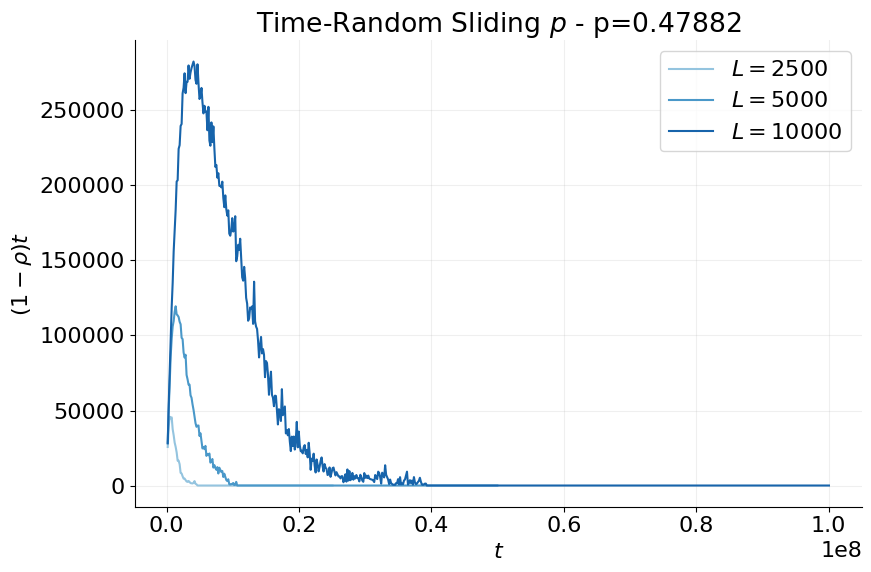

In [10]:
for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot(times[order],
                (1 - mean_rhos[key][order])*times[order],
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$(1 - \rho)t$")
    ax.legend()
    fig.tight_layout()
    plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_31845/4272393083.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10((1 - mean_rhos[key][order])),


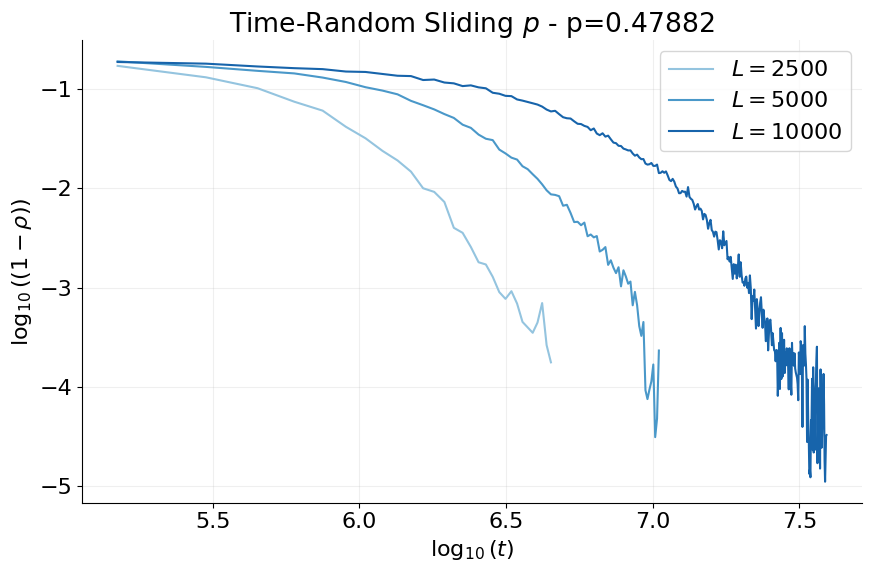

In [11]:
# With the production L_vals=[20000], this visualizes the proposed collapse.
# Use several L values in the producer to estimate z from the collapse.
delta_guess = 0.094
z_guess = 1.45

for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot(np.log10(times[order]),
                np.log10((1 - mean_rhos[key][order])),
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}")
    ax.set_xlabel(r"$\log_{10}(t)$")
    ax.set_ylabel(r"$\log_{10}((1 - \rho))$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_z_p{float_str(critical_control)}.png", dpi=200)
    plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_31845/2252127846.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10((1 - mean_rhos[key][order]) * times[order] ** delta_guess),


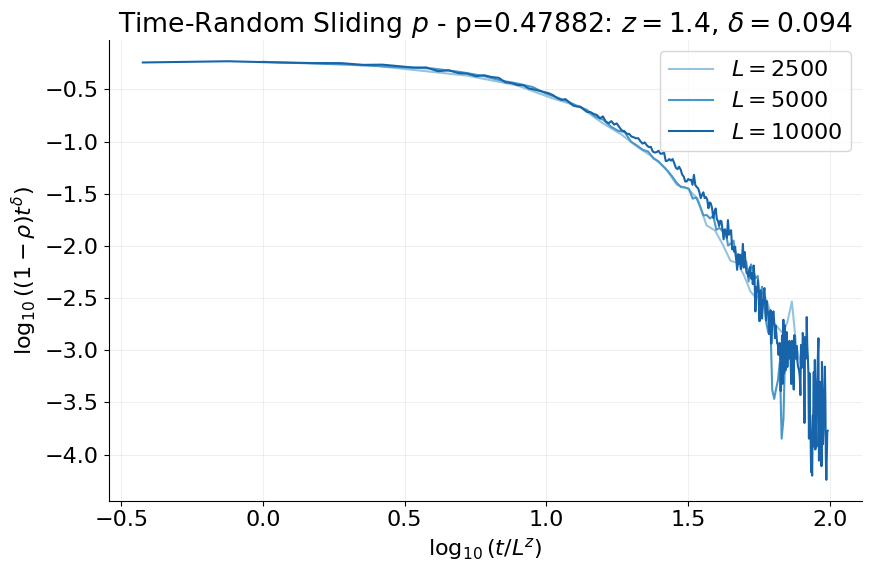

In [12]:
# With the production L_vals=[20000], this visualizes the proposed collapse.
# Use several L values in the producer to estimate z from the collapse.
delta_guess = 0.094
z_guess = 1.40

for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot(np.log10(times[order] / L_val ** z_guess),
                np.log10((1 - mean_rhos[key][order]) * times[order] ** delta_guess),
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}: $z={z_guess}$, $\delta={delta_guess}$")
    ax.set_xlabel(r"$\log_{10}(t/L^z)$")
    ax.set_ylabel(r"$\log_{10}((1 - \rho)t^\delta)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_z_collapse_p{float_str(critical_control)}.png", dpi=200)
    plt.show()


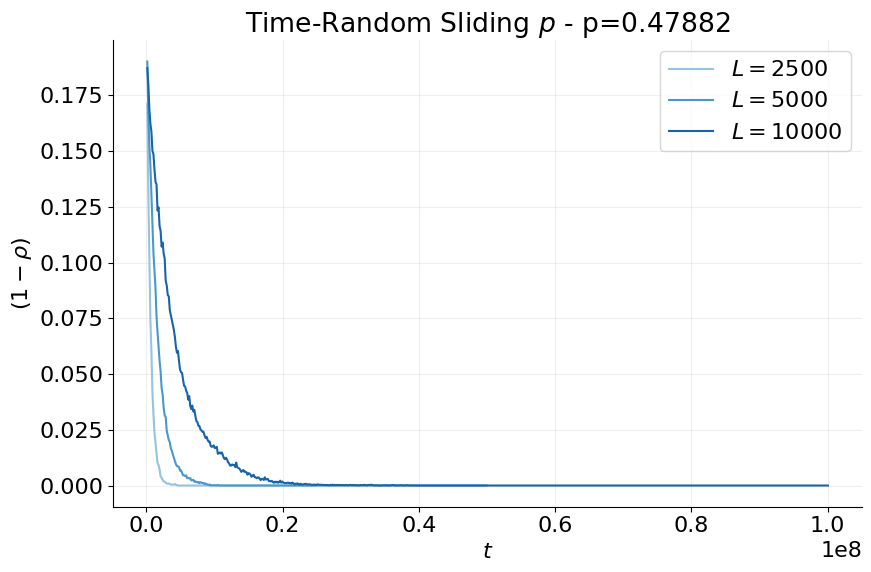

In [ ]:
# With the production L_vals=[20000], this visualizes the proposed collapse.
# Use several L values in the producer to estimate z from the collapse.
alpha_guess = 1.0
z_guess = 1.0

for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot(times[order],
                (1 - mean_rhos[key][order]),
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}")
    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$(1 - \rho)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_z_p{float_str(critical_control)}.png", dpi=200)
    plt.show()

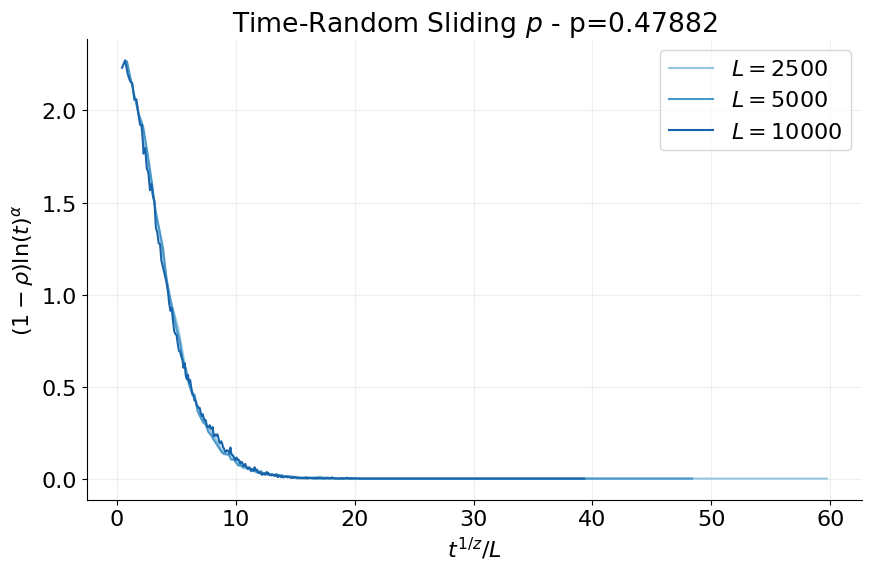

In [33]:
# With the production L_vals=[20000], this visualizes the proposed collapse.
# Use several L values in the producer to estimate z from the collapse.
alpha_guess = 1.0
z_guess = 1.43

for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot((times[order])**(1/z_guess) / L_val,
                (1 - mean_rhos[key][order])*np.log(times[order]) ** alpha_guess,
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}")
    ax.set_xlabel(r"$t^{1/z}/L$")
    ax.set_ylabel(r"$(1 - \rho)\ln(t)^\alpha$")
    # ax.set_xlim(-0.05, 20)
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_z_p{float_str(critical_control)}.png", dpi=200)
    plt.show()

/var/folders/0k/n4x5z88x1rx124p1g1l55hmc0000gn/T/ipykernel_31845/4111333571.py:14: RuntimeWarning: divide by zero encountered in log10
  np.log10((1 - mean_rhos[key][order]) * np.log(times[order]) ** alpha_guess),


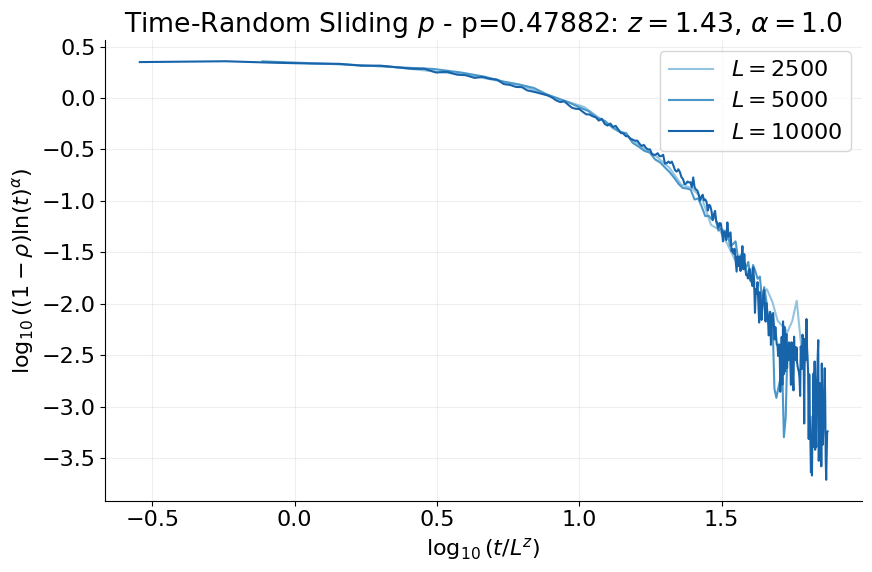

In [36]:
# With the production L_vals=[20000], this visualizes the proposed collapse.
# Use several L values in the producer to estimate z from the collapse.
alpha_guess = 1.0
z_guess = 1.43

for critical_control in control_vals:
    fig, ax = plt.subplots(figsize=(9, 6))
    cmap = plt.colormaps.get_cmap("Blues").resampled(len(L_vals) + 3)
    for i, L_val in enumerate(L_vals):
        key = (L_val, min(control_vals, key=lambda value: abs(value - critical_control)))
        times = time_vals[key]
        order = times > 0
        ax.plot(np.log10(times[order] / L_val ** z_guess),
                np.log10((1 - mean_rhos[key][order]) * np.log(times[order]) ** alpha_guess),
                color=cmap(i + 2), label=fr"$L={L_val}$")
    ax.set_title(fr"{model_label} - p={critical_control}: $z={z_guess}$, $\alpha={alpha_guess}$")
    ax.set_xlabel(r"$\log_{10}(t/L^z)$")
    ax.set_ylabel(r"$\log_{10}((1 - \rho)\ln(t)^\alpha)$")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_ROOT / f"rho_per_time_z_collapse_p{float_str(critical_control)}.png", dpi=200)
    plt.show()
